In [76]:
import uproot
import pandas as pd
import numpy as np
import glob


In [77]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [78]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [79]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [80]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,238579.000000,238579.000000,238579.000000,238579.000000,238579.000000
mean,1.765997,0.246005,0.446826,1.632171,-0.007943
std,0.154232,0.469820,0.455947,0.865300,0.999971
min,1.500001,-0.992339,-0.892514,0.400005,-1.000000
25%,1.637663,-0.113705,0.137672,0.907050,-1.000000
50%,1.749157,0.324485,0.588216,1.515255,-1.000000
75%,1.886033,0.640256,0.836641,2.217184,1.000000
max,2.099998,0.999992,0.977868,5.784096,1.000000


In [81]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [82]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,146120.000000,146120.000000,146120.000000,146120.000000,146120.000000
mean,1.866533,0.226811,0.434420,1.657593,-0.008979
std,0.103389,0.477526,0.465009,0.890580,0.999963
min,1.700001,-0.992339,-0.892306,0.400005,-1.000000
25%,1.768042,-0.146573,0.110600,0.911911,-1.000000
50%,1.868319,0.295292,0.578414,1.539375,-1.000000
75%,1.964784,0.628851,0.835581,2.254647,1.000000
max,2.099998,0.999989,0.977868,5.784096,1.000000


In [83]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [84]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_noD0"
cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [85]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [86]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,840593.000000,840593.000000,840593.000000,840593.000000,840593.000000
mean,1.763196,0.218631,0.414267,1.634547,-0.002333
std,0.153292,0.473628,0.456225,0.835627,0.999998
min,1.500001,-0.994890,-0.900063,0.400009,-1.000000
25%,1.636147,-0.149188,0.093983,0.946522,-1.000000
50%,1.744449,0.290719,0.536510,1.524003,-1.000000
75%,1.886770,0.617541,0.807169,2.191035,1.000000
max,2.099997,0.999983,0.978023,7.185888,1.000000


In [87]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.7 & Dp_M<2.1')


In [88]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,507970.000000,507970.000000,507970.000000,507970.000000,507970.000000
mean,1.865021,0.198528,0.399597,1.658321,-0.000646
std,0.102641,0.480728,0.464840,0.856029,1.000001
min,1.700000,-0.994890,-0.900063,0.400010,-1.000000
25%,1.765905,-0.181089,0.063472,0.955686,-1.000000
50%,1.868257,0.261651,0.521931,1.546760,-1.000000
75%,1.965144,0.604766,0.803704,2.223872,1.000000
max,2.099997,0.999983,0.978023,7.185888,1.000000


In [89]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [90]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [91]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


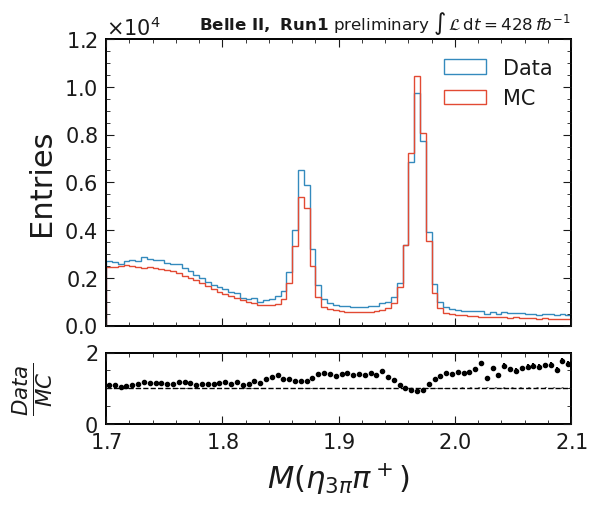

In [92]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}.png", bbox_inches="tight")